# Tutorial about fluopy

Here we outline the principle use of fluopy.

In [1]:
from pprint import pprint

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

import fluopy
import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

In [2]:
fluopy.__version__

'0.1.0.dev218+g6a7acd3b1.d20250915'

For random number generation a Generator is initialized.

In [3]:
rng = np.random.default_rng(seed=1)

## Modules

Fluopy contains the following modules. For detailed information look up the API documentation.

In [4]:
print("Fluopy modules:")
print()
pprint([item for item in dir(fluopy) if not item.startswith("_")])

Fluopy modules:

['analysis',
 'blinking',
 'distributions',
 'emissions',
 'fcs',
 'figure',
 'fitting',
 'fluo_data',
 'fluorophores',
 'formulas',
 'kappa_squared',
 'logger',
 'logging',
 'miscellaneous',
 'network',
 'prediction',
 'routines',
 'simulation',
 'simulation_tcspc',
 'transitions']


## Introduction

Fluopy helps to run Markov chain simulations for a photophysical system of isolated or communicating fluorophores.

To get started the photophysical system has to be defined and instantiated.

This consists of the following steps:

* Define a fluorophore system that contains fluorophores at positions in a 2D space.
* Define a set of possible transitions for the fluorophore system.

A simulation provides a series of transition events that occured in a single realization of the Markov chain.

A simulation is run for a given fluorophore system and transition set with a random number generator initialized as seed.

For a fluorophore system and transition set that fullfill certain requirements a prediction for the simulation outcome can be derived based on computational estimation of a steady-state equilibrium.

Finally, the acquired data is analysed and presented in various formats.

Analysis procedure that focus on experimentally observable transitions are available:

* Time traces
* Fluorescence correlation spectroscopy
* ON/Off time distributions

A simulation with pulsed excitation can be carried out. The analysis resembles a TSCPC experiment.

A typical setup, simulation and analysis procedure for selected photophysical systems is presented in the other tutorials. 

In the following we will present the relevant code blocks.

### Naming conventions

|name|meaning|
|---|---|
|SingleState|photophysical state|
|PairedState|SingleStates of donor and acceptor combined|
|Transition|constant and variable attributes of photophysical transition|
|combined states|combinations of SingleStates depending on number of fluorophores|
|combined state transition|transitions between combined states|
|realizable|theoretically possible|
|resample|frame integration time|

## Transitions

There are various transition types that connect the photophysical states:

In [5]:
list(tr.TransitionType.__members__)

['EXCITATION',
 'FLUORESCENT_EMISSION',
 'SINGLET_QUENCHING',
 'INTERSYSTEM_CROSSING_ST',
 'INTERSYSTEM_CROSSING_TS',
 'INTERNAL_CONVERSION_S',
 'REVERSE_INTERSYSTEM_CROSSING',
 'PHOTOBLEACHING_1',
 'PHOTOBLEACHING_2',
 'ET_CYCLE_T',
 'ET_CYCLE_S',
 'ADDUCT_T',
 'ADDUCT_S',
 'THERM_ELIMINATION',
 'PHOTO_UNCAGING',
 'RAD_ESCAPE',
 'RAD_RELAX',
 'ISOMERIZATION',
 'PHOTO_BISO',
 'THERM_BISO',
 'FRET',
 'CIS_FRET_1',
 'CIS_FRET_2',
 'OFF_FRET_1',
 'OFF_FRET_2',
 'S_S_ANNIHILATION',
 'S_T_ANNIHILATION',
 'S_T_ANNI_RISC',
 'S_T_ANNI_BLEACH',
 'H2O_ATTACK_S',
 'H2O_ATTACK_T',
 'BACK_REACTION',
 'S1_S0_TRANSITIONS',
 'CIS_S0_TRANSITIONS',
 'T1_S0_TRANSITIONS',
 'OFF_S0_TRANSITIONS']

Photophysical states are named according to the Enum class `tr.SingleState` and `tr.PairedState`, which link state IDs to photophysical state names.

A single fluorophore can occupy the following photophysical states:

In [6]:
list(tr.SingleState.__members__)

['S0', 'S1', 'S2', 'T1', 'T2', 'B', 'cis', 'OFF', 'OFF2', 'R']

Two interacting fluorophores can occupy the following (paired) photophysical states:

In [7]:
list(tr.PairedState.__members__)

['S1_S0',
 'S0_S1',
 'S1_T1',
 'S1_Cis',
 'S0_Cis',
 'S1_OFF',
 'S0_S0',
 'S0_T2',
 'S1_S1',
 'S0_T1',
 'S0_OFF2',
 'S0_OFF',
 'S0_B']

A specific transition of a certain type from state 1 to state 2 is defined as:

In [8]:
transition = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[1]
)
pprint(transition)

Transition(identity=None,
           transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>,
           abbreviation='EXC',
           initial_state=<SingleState.S0: 0>,
           final_state=<SingleState.S1: 1>,
           rate=1000000.0,
           photon=False,
           fluorophore_ids=[1])


A photophysical system is made up of one or more fluorophores or fluorophore pairs with multiple transitions:

In [9]:
transition_1 = tr.Transition(
    tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0]
)
transition_2 = tr.Transition(
    tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0]
)
transitions = {
    "cy5_dna": [transition_1, transition_2],
}
pprint(transitions)

{'cy5_dna': [Transition(identity=None,
                        transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>,
                        abbreviation='EXC',
                        initial_state=<SingleState.S0: 0>,
                        final_state=<SingleState.S1: 1>,
                        rate=1000000.0,
                        photon=False,
                        fluorophore_ids=[0]),
             Transition(identity=None,
                        transition_type=<TransitionType.FLUORESCENT_EMISSION: TransitionAttributes(abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=True)>,
                        abbreviation='FLU',
                        initial_state=<SingleState.S1: 1>,
                        final_state=<SingleState.S0: 0>,
                        rate=1000000000.0,
                        photon=True,
   

## The fluorophore system

A photophysical system is defined by one or more fluorophores that occupy electronic states and go through transitions from one state to another.

A number of input parameters are kept in fluopy.fluo_data as FluorophoreData instances. These are automatically inserted if the name matches.

In [65]:
fluorophore = fl.Fluorophore(name="some_dye", position=[0, 0])
pprint(fluorophore)

There is no FluorophoreData for Fluorophore some_dye in fluopy.fluo_data. Parameters have to be defined manually.


Fluorophore(identity=None,
            name='some_dye',
            position=array([0, 0]),
            constants=None)


In [10]:
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
pprint(fluorophore)

Fluorophore(identity=None,
            name='cy5_dna',
            position=array([0, 0]),
            constants=FluorophoreData(data_files='cy5_data',
                                      QUANTUM_YIELD=0.27,
                                      FLUORESCENCE_LIFETIME=1.7e-09,
                                      S1_QUENCH_RATE=0,
                                      ISC_ST_RATE=830000.0,
                                      ISC_TS_RATE=5000.0,
                                      RISC_RATE=0,
                                      STA_EFFICIENCY=0,
                                      PHOTOBLEACH_T1_RATE=10.0,
                                      PHOTOBLEACH_T2_RATE=0,
                                      DSTORM_PET_T_RATE_MOL=100000000.0,
                                      DSTORM_PET_S_RATE_MOL=1000000000.0,
                                      DSTORM_PET_SUCCESS_RATE=0.001,
                                      DSTORM_TH_EL_RATE_1=0.01,
                                   

A fluophore system contains  the fluorophore identities, their spatial arrangement and transition rate constants.

In [11]:
fluorophores = [fluorophore]
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

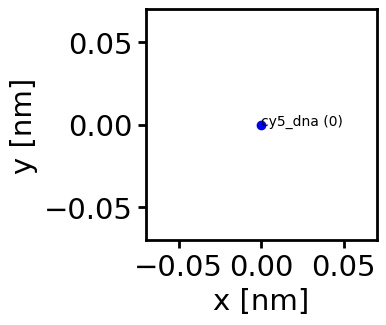

In [12]:
fluorophore_system.plot(scale=1, quadratic=True);

## Fluorophore data

The transition rate constants are specific for a kind of fluorophore and the chemical environment. 

Standard datasets with all constant photophysical attributes of the fluorophore are defined for various fluorophores.

In [13]:
pprint(fluopy.fluo_data.atto643)

FluorophoreData(data_files='atto643_data',
                QUANTUM_YIELD=0.6,
                FLUORESCENCE_LIFETIME=3e-09,
                S1_QUENCH_RATE=0,
                ISC_ST_RATE=1000000.0,
                ISC_TS_RATE=100000.0,
                RISC_RATE=0,
                STA_EFFICIENCY=0,
                PHOTOBLEACH_T1_RATE=1,
                PHOTOBLEACH_T2_RATE=0,
                DSTORM_PET_T_RATE_MOL=0,
                DSTORM_PET_S_RATE_MOL=0,
                DSTORM_PET_SUCCESS_RATE=0,
                DSTORM_TH_EL_RATE_1=0,
                DSTORM_TH_EL_RATE_2=0,
                DSTORM_P_EL_CROSS_SECTION=0,
                RAD_ESCAPE_EFFICIENCY=0,
                RAD_RELAX_RATE=0,
                OFRET_EFFICIENCY=0,
                ISO_RATE=0,
                BISO_CROSS_SECTION=0,
                BISO_THERMAL_RATE=0,
                BISO_EFFICIENCY=0,
                H2O_ATTACK_S=30000.0,
                H2O_ATTACK_T=0,
                BACK_REACTION=0.1)


In [14]:
pprint(fluopy.fluo_data.cy5_dna)

FluorophoreData(data_files='cy5_data',
                QUANTUM_YIELD=0.27,
                FLUORESCENCE_LIFETIME=1.7e-09,
                S1_QUENCH_RATE=0,
                ISC_ST_RATE=830000.0,
                ISC_TS_RATE=5000.0,
                RISC_RATE=0,
                STA_EFFICIENCY=0,
                PHOTOBLEACH_T1_RATE=10.0,
                PHOTOBLEACH_T2_RATE=0,
                DSTORM_PET_T_RATE_MOL=100000000.0,
                DSTORM_PET_S_RATE_MOL=1000000000.0,
                DSTORM_PET_SUCCESS_RATE=0.001,
                DSTORM_TH_EL_RATE_1=0.01,
                DSTORM_TH_EL_RATE_2=0,
                DSTORM_P_EL_CROSS_SECTION=6e-24,
                RAD_ESCAPE_EFFICIENCY=0.01,
                RAD_RELAX_RATE=1300.0,
                OFRET_EFFICIENCY=0.001,
                ISO_RATE=4000000.0,
                BISO_CROSS_SECTION=6e-18,
                BISO_THERMAL_RATE=5000.0,
                BISO_EFFICIENCY=0.04,
                H2O_ATTACK_S=0,
                H2O_ATTACK_T=0,
 

The data is collected in a dataclass specifying possible constants `fluopy.fluo_data.FluorophoreData`.

In [15]:
fluorophore_data = fluopy.fluo_data.FluorophoreData()
pprint(fluorophore_data)

FluorophoreData(data_files=None,
                QUANTUM_YIELD=0,
                FLUORESCENCE_LIFETIME=0,
                S1_QUENCH_RATE=0,
                ISC_ST_RATE=0,
                ISC_TS_RATE=0,
                RISC_RATE=0,
                STA_EFFICIENCY=0,
                PHOTOBLEACH_T1_RATE=0,
                PHOTOBLEACH_T2_RATE=0,
                DSTORM_PET_T_RATE_MOL=0,
                DSTORM_PET_S_RATE_MOL=0,
                DSTORM_PET_SUCCESS_RATE=0,
                DSTORM_TH_EL_RATE_1=0,
                DSTORM_TH_EL_RATE_2=0,
                DSTORM_P_EL_CROSS_SECTION=0,
                RAD_ESCAPE_EFFICIENCY=0,
                RAD_RELAX_RATE=0,
                OFRET_EFFICIENCY=0,
                ISO_RATE=0,
                BISO_CROSS_SECTION=0,
                BISO_THERMAL_RATE=0,
                BISO_EFFICIENCY=0,
                H2O_ATTACK_S=0,
                H2O_ATTACK_T=0,
                BACK_REACTION=0)


## Transition set

A set of possible transitions can be generated from a given fluorophore system by helper functions:

In [16]:
transitions = fluorophore_system.load_transitions(
    summarize=False,
    irradiance=2.5,
    wavelength=640,
    bleaching=False,
    energy_transfer=False,
    dstorm=False,
)
pprint(transitions)

{'cy5_dna': [Transition(identity=None,
                        transition_type=<TransitionType.EXCITATION: TransitionAttributes(abbreviation='EXC', initial_state=<SingleState.S0: 0>, final_state=<SingleState.S1: 1>, photon=False)>,
                        abbreviation='EXC',
                        initial_state=<SingleState.S0: 0>,
                        final_state=<SingleState.S1: 1>,
                        rate=np.float64(7269625.549132028),
                        photon=False,
                        fluorophore_ids=[0]),
             Transition(identity=None,
                        transition_type=<TransitionType.FLUORESCENT_EMISSION: TransitionAttributes(abbreviation='FLU', initial_state=<SingleState.S1: 1>, final_state=<SingleState.S0: 0>, photon=True)>,
                        abbreviation='FLU',
                        initial_state=<SingleState.S1: 1>,
                        final_state=<SingleState.S0: 0>,
                        rate=np.float64(158823529.4117647),
   

A transition set has to be defined from the individual transitions for a given fluorophore system:

In [17]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)

TransitionSet provides helper methods so that a transition_set can be easily modified with the following methods:

In [18]:
transition_set_no_bleaching = transition_set.remove_absorbing_states()
transition_set_no_ets = transition_set.remove_energy_transfers()
transition_set_filtered = transition_set.filter_by_identity(remove_list=[6])

transition_set_adj = transition_set.adjust_rates(
    change_dict={1: 1e3}, keep_zero_rates=False
)

If for no other reasons you should remove transitions with rate constants of zero (this has possibly already been done above through keep_zero_rates=False):

In [19]:
transtition_set = transition_set.remove_zero_rates()

A transition set has to be finalized before a simulation is started:

In [20]:
transition_set.finalize()
list(vars(transition_set).keys())

['transitions',
 'fluorophore_system',
 'transition_df',
 'single_states',
 '_combined_state_transitions_df',
 '_row_sums',
 '_transition_matrix']

A graphical representation of all possible transitions is given:

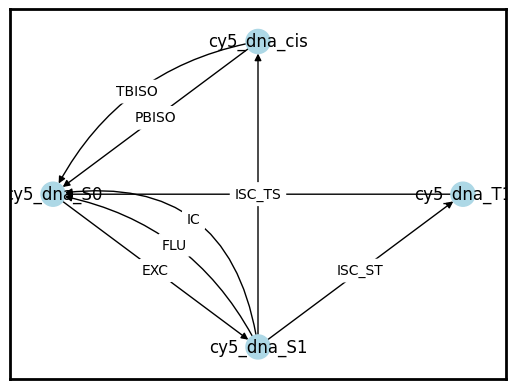

In [21]:
transition_set.plot(graph_type="shell", colors=None, scale=1);

All transitions are listed in the `transitions`attribute or in a dataframe:

In [22]:
transition_set.transition_df

transition_type abbreviation  \
Fluorophore identity                                                        
cy5_dna     0                      TransitionType.EXCITATION          EXC   
            1            TransitionType.FLUORESCENT_EMISSION          FLU   
            2         TransitionType.INTERSYSTEM_CROSSING_ST       ISC_ST   
            3         TransitionType.INTERSYSTEM_CROSSING_TS       ISC_TS   
            4                   TransitionType.ISOMERIZATION          ISO   
            5                      TransitionType.PHOTO_BISO        PBISO   
            6                      TransitionType.THERM_BISO        TBISO   
            7           TransitionType.INTERNAL_CONVERSION_S           IC   

                        initial_state      final_state          rate  photon  \
Fluorophore identity                                                           
cy5_dna     0          SingleState.S0   SingleState.S1  7.269626e+06   False   
            1          SingleState.S1   SingleState.S0  1.588235e+08    True   
            2          SingleState.S1   SingleState.T1  8.300000e+05   False   
            3          SingleState.T1   SingleState.S0  5.000000e+03   False   
            4          SingleState.S1  SingleState.cis  4.000000e+06   False   
            5         SingleState.cis   SingleState.S0  4.832752e+04   False   
            6         SingleState.cis   SingleState.S0  5.000000e+03   False   
            7          SingleState.S1   SingleState.S0  4.245818e+08   False   

                     fluorophore_ids  absorbing  
Fluorophore identity                             
cy5_dna     0                    [0]      False  
            1                    [0]      False  
            2                    [0]      False  
            3                    [0]      False  
            4                    [0]      False  
            5                    [0]      False  
            6                    [0]      False  
            7                    [0]      False

Note: In transition_set.single_states, only the 'relevant' states are mentioned - the ones that actually occur in transition_set.plot().

Note: Transitions that have a rate of 0 or are not usable by the fluorophore do not occur transition_set.single_states; however, transitions that may not be reachable still do.

## Single dye simulation setup

For further demonstration we set up a simple fluorophore system that contains a single Cy5 fluorophore.

### Define the fluorophore system

In [23]:
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])

### Define the transition set

In [24]:
transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2,
    wavelength=640,
    bleaching=False,
    energy_transfer=False,
    dstorm=False,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.remove_energy_transfers()
transition_set.finalize()

## Make a prediction

For a fluorophore system and transition set that fullfill certain requirements a prediction for the simulation outcome can be derived based on computational estimation of a steady-state equilibrium.

In [25]:
prediction = pr.Prediction(transition_set)
list(vars(prediction).keys())

['energy_transfer',
 'absorbing_chain',
 'transition_set',
 'frequency_transitions',
 'frequency_states',
 'transition_time_distributions',
 'lifetime_distributions',
 'mean_transition_times',
 'mean_lifetimes',
 'state_occupations']

The results are accessible through methods of the prediction instance.

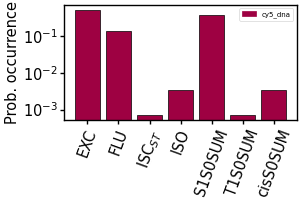

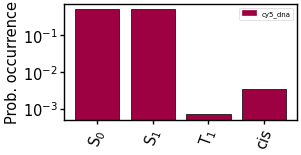

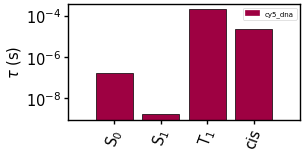

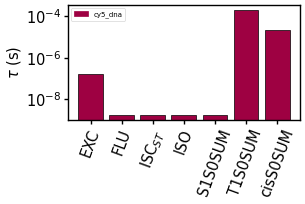

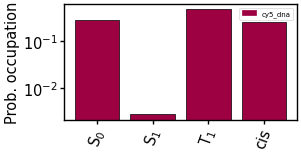

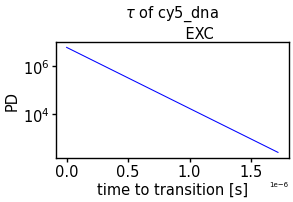

In [26]:
prediction.plot_frequency_transitions(scale=0.5)
prediction.plot_frequency_states(scale=0.5)
prediction.plot_mean_lifetimes(scale=0.5)
prediction.plot_mean_transition_times(scale=0.5)
prediction.plot_state_occupations(scale=0.5)
prediction.plot_transition_time_distributions(
    fluorophore="cy5_dna", transition_id=0, scale=0.5
);

Note for multi-fluorophore systems:
* if energy transfers occur, pairs have separate color in plot but are normalized with other transitions of their donor
* absorbing states: the prediction works using the fundamental matrix. For Q, the transitions leading to an OVERALL absorbed state are dropped. This can be done since bleaching is usually by far the least occurring transition, meaning each fluorophore will reach its limiting distribution (as if it was no absorbing Markov Chain)
        the frequencies and state occupations of absorbing transitions and states are set to 0, their lifetimes to inf (this is different to analysis, where - if absorbing transitions happened - only the lifetime and the state occupation is 0)



## Run a simulation

To carry out the complete Markov chain simulation, a Simulation object has to be instantiated from the transition set.

The simulation can then run for a given number of transition steps, or until it reaches a defined end time.

In [27]:
%%time
simulation = si.Simulation(transition_set)
list(vars(simulation).keys())

CPU times: total: 0 ns
Wall time: 46.7 μs


['transition_set',
 'time_series',
 'transition_series',
 'state_series',
 'memmap_path']

In [28]:
%%time
# simulate until it reaches given end_time
simulation.run(start_at=None, size=1e6, end_time=1, seed=rng, use_memmap=None)
mi.print_class(simulation)

Floating point precision error warning:
 The smallest safe increment is 2.22e-16.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1]
 gives a probability of 1.31e-07 for a smaller increment to be drawn.


Attributes of <fluopy.simulation.Simulation object at 0x00000236AC723230>:
.................................................................
transition_set = <fluopy.transitions.TransitionSet object at 0x00000236AC7DD590>
_________________________________________________________________
time_series = array([0.00000000e+00, 1.15167401e-07, 1.1846001....99893691e-01, 1.00000000e+00], shape=(3302282,))
_________________________________________________________________
transition_series = array([0, 4, 0, ..., 4, 0, 2], shape=(3302280,), dtype=uint32)
_________________________________________________________________
state_series = array([[0, 1, 0, ..., 0, 1, 3]], shape=(1, 3302281), dtype=int8)
_________________________________________________________________
memmap_path = None
_________________________________________________________________


CPU times: total: 17.5 s
Wall time: 17.6 s


If the simulation goes through many transtition events, the arrays may become too large for the available RAM.
In that case, use memory maps to store the data on the local drive.

## Run an approximate simulation

Under certain requirements (similar to prediction) a simulation approximation can can be carried out, saving time.

In [29]:
%%time
approximation = si.Simulation(transition_set=transition_set)
approximation.approximate(prediction=prediction, size=1e6, seed=rng)
list(vars(approximation).keys())

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


CPU times: total: 203 ms
Wall time: 188 ms


['transition_set',
 'time_series',
 'transition_series',
 'state_series',
 'memmap_path']

## Analyze the simulation

Analyze the data from a given simulation for state probabilities and lifetimes, among others.

In [30]:
analysis = an.Analysis(simulation=simulation)
list(vars(analysis).keys())

['simulation',
 'frequency_transitions',
 'frequency_states',
 'transition_time_distributions',
 'lifetime_distributions',
 'mean_transition_times',
 'mean_lifetimes',
 'state_occupations']

In [31]:
mi.print_class(analysis)

Attributes of <fluopy.analysis.Analysis object at 0x00000236AC722510>:
.................................................................
simulation = <fluopy.simulation.Simulation object at 0x00000236AC723230>
_________________________________________________________________
frequency_transitions = array([0.4979499 , 0.13429449, 0.00072193, 0.00337857, 0.35955491,
       0.00072162, 0.00337857])
_________________________________________________________________
frequency_states = {'cy5_dna': array([0.49794975, 0.49794975, 0.00072193, 0.00337857])}
_________________________________________________________________
transition_time_distributions = [array([1.15167401e-07, 2.00370096e-07, 1.0292415....05830117e-08, 1.19170847e-08], shape=(1644370,)), array([2.70692572e-09, 1.04365849e-09, 1.1245765...1.39646961e-10, 7.48977991e-10], shape=(443478,)), array([8.13131906e-11, 1.12316807e-09, 3.2367626..., 5.24545962e-10, 1.79783488e-09], shape=(2384,)), array([2.78520369e-11, 4.96192071e-11, 5.2

In the following analysis plots the simulation results are overlaid with prediction outcomes (crosses) if a prediction is provided.

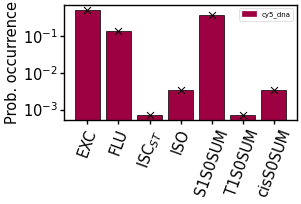

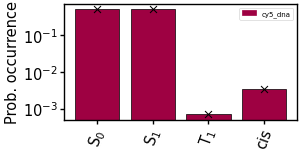

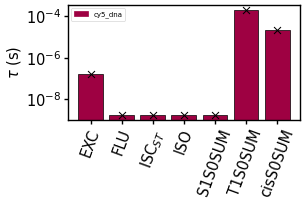

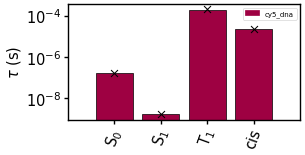

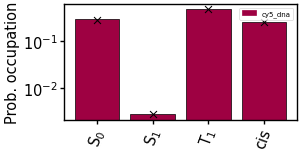

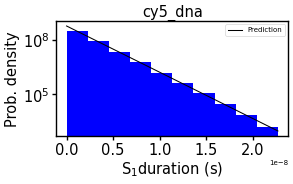

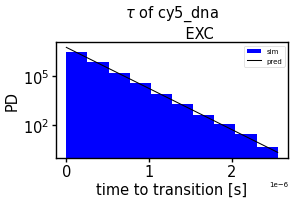

In [32]:
analysis.get_fluorescence_lifetimes(fluorophore="cy5_dna")
analysis.get_emitting_transition_lifetimes(fluorophore="cy5_dna")

analysis.plot_frequency_transitions(scale=0.5, prediction=prediction)
analysis.plot_frequency_states(scale=0.5, prediction=prediction)
analysis.plot_mean_transition_times(scale=0.5, prediction=prediction)
analysis.plot_mean_lifetimes(scale=0.5, prediction=prediction)
analysis.plot_state_occupations(scale=0.5, prediction=prediction)
analysis.plot_lifetime_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", state_identity=1
)
analysis.plot_transition_time_distributions(
    scale=0.5, prediction=prediction, fluorophore="cy5_dna", transition_id=0
);

Note for multi-fluorophore systems:

* The analysis follows these rules:

    * time to transitions of energy transfers are collected only from the donor's point of view.

    * time to transition of e.g., fluorescence, does not differentiate whether energy transfer was also an option or not one energy transfer transition occurrence resembles the transition of the donor and the acceptor state lifetimes and occurrences do not differentiate whether energy transfer was involved or not.

* Energy transfer has an impact on true fluorescence lifetime only if the acceptors are truly available. If the potential acceptor is in a non-accepting state, the energy transfer is not available. If multiple fluorophores are potential acceptors, all of their respective rates are taken into account. Depending on the photophysical system, energy transfers may only have a marginal impact on the mean fluorescence lifetime.


## Simulation of experimentally observable (photons per frames) only

If you are not interested in all hidden state transitions but only in the observable photon emission events, you can limit the simulation to the relevant transitions.

This approach requires less memory than a full simulation. 

However, the complete statistical analysis is not available. A photon time series, FCS and blinking analysis is available.

The observation of emitted photons is further influenced by spectral filters, optical elements and detector noise contributions.

For multicolor fluorophore-systems, instantiate two Emissions objects with different bandpasses.

#### Extract photon emission events from simulation

In [33]:
%%time
emissions = em.Emissions(frame_time="5ms", seed=rng, bandpass=(600, 800))
emissions.extract(simulation=simulation)
emissions

CPU times: total: 297 ms
Wall time: 328 ms


#### Simulate photon emission events

Helper routines are available to further modify the emission time series and correct for detection efficiency and noise contributions:

In [34]:
emissions.add_photon_collection_objective(p=0.1, seed=rng)  # 1.
emissions.add_quantum_efficiency(p=0.9, seed=rng)  # 3.1.
emissions.add_poisson_noise(
    rate=0.05, seed=rng
)  # 3.2. (dark noise), note the frame time
emissions.add_emccd_gain(emccd_gain=10, seed=rng)  # 4.
emissions.add_gaussian_noise(mean=10, std=1, seed=rng)  # 5. (readout noise)

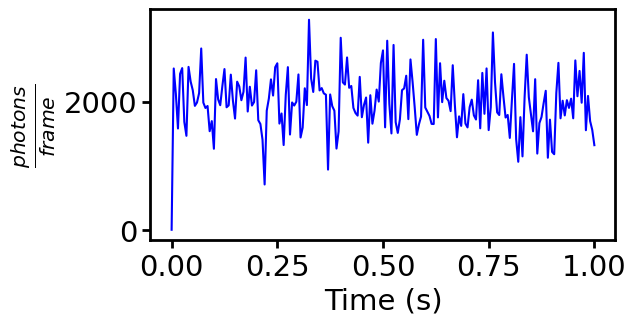

In [35]:
emissions.plot_time_series();

## Simulation of pulsed excitation

A simulation of observable photon emissions with pulsed laser excitation can be carried out. The analysis resembles a TSCPC experiment.

In this simulation, the returned lifetimes are the time differences of photon emission to the last laser pulse. I.e., if the time between laser pulses is very short, it may shorten the observed lifetimes. 

The simulation does not discriminate between multiple identical fluorophores (i.e., if one fluorophore gets excited, it transfers the energy to another fluorophore, and this fluorophore emits a photon). 

However, if the fluorophores are different, only one of them may be directly excitable by the laser pulse (due to the wavelength) and, depending on the provided bandpass, only the fluorescence of the other may be detected.

If details is True, a complete simulation object will be returned with transition_series, state_series and time_series (requiring more memory). 

In [36]:
%%time
emissions_tcspc = em.Emissions(frame_time="10us", seed=rng, bandpass=(600, 800))
lifetimes_DA, lifetimes_D, lifetimes_all = emissions_tcspc.tcspc(
    transition_set=transition_set,
    number_pulses=1e5,
    pulse_duration=1e-11,
    time_between_pulses=1e-7,
    excitation_rates={"cy5_dna": 1e11},
    size=1e5,
    store_time_points=True,
    # details = True
)

the last frame (of index 0.01) has 1.00e+00 times the pulses of other frames.


CPU times: total: 3.62 s
Wall time: 3.66 s


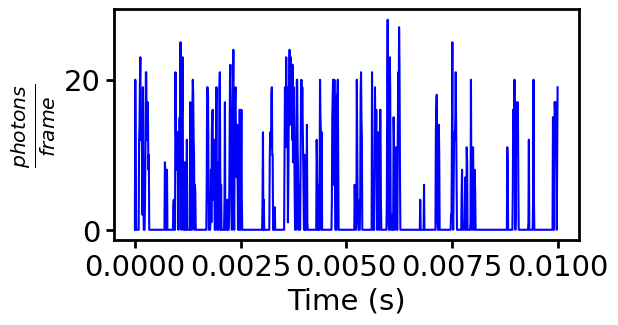

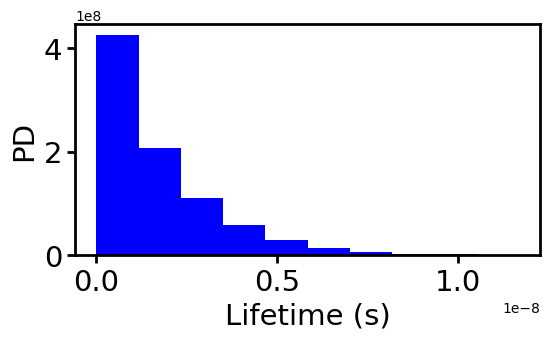

In [37]:
emissions_tcspc.plot_time_series()
fi.universal_figure(
    type_="hist", data=lifetimes_all, ylabel="PD", density=True, xlabel="Lifetime (s)"
);

Note:

Since the TCSPC simulation assumes a laser pulse to be instantaneous, a laser pulse that excited multiple fluorophores will lead to duplicates in the time series. This is handled by introducing minimal amount of spaces between these duplicates. The excitations are added in the correct order (fluorophore-specific) such that these series exactly represent the transition chain, even with multiple different distances between energy transfer partners. Note that when monitoring the fluorescence lifetime via the simulation object it will be the true one (as opposed to the generally returned lifetimes, which are the observed ones).

Note: 

For simulting homo-FRET the extra homo-FRET notebook is still better suited to simulate an idealized homo-FRET scenario, because there the between-pulse-time will always be sufficiently large.

## Fluorescence correlation spectroscopy

Observed fluorescence emission events can be analyzed by a correlation analysis.

In [38]:
fcs = fcs_p.FCS(emissions)
list(vars(fcs).keys())

['emissions', 'autocorrelation', 'tau']

### Autocorrelation of time points

The autocorrelation can be computed on the exact time points (being limited by the smallest available time difference).

In [70]:
%%time
fcs.autocorrelate_time_points(
    exp_min=-16, exp_max=0, points_per_base=4, base=4, normalize=True
)

The exp_max 0 yields a base to the power of exp_max 1 that is larger than the last time point 0.9998935849738816. Therefore, exp_max is adjusted to -1.


CPU times: total: 203 ms
Wall time: 209 ms


Attributes of <fluopy.fcs.FCS object at 0x00000236AC722E40>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000236AC721160>
_________________________________________________________________
autocorrelation = array([0.68531317, 0.48458959, 0.68531317, 1.230... 1.0166399 , 1.02127411, 1.03142128, 1.05049859])
_________________________________________________________________
tau = array([2.81051449e-10, 3.97466771e-10, 5.6210289... 1.06694174e-01, 1.50888348e-01, 2.13388348e-01])
_________________________________________________________________




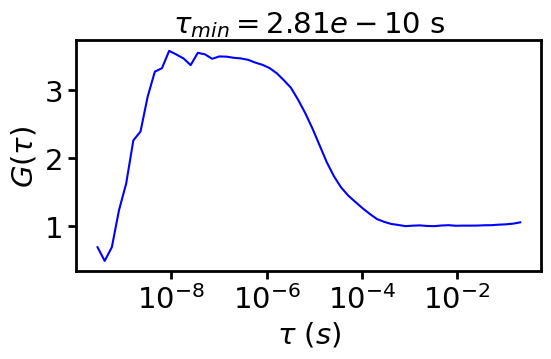

In [71]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

### Autocorrelation of time series

The autocorrelation can be computed on the binned time series (being limited by the time bin).

There is not much to be seen in this example, since the bin time is larger than all relevant fluctuation time scales.

In [41]:
fcs.autocorrelate_time_series(log=True, m=4, normalize=True)

Attributes of <fluopy.fcs.FCS object at 0x00000236AC722E40>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000236AC721160>
_________________________________________________________________
autocorrelation = array([1.00211007, 1.00070264, 1.0035714 , 0.997... 0.99998845, 0.99884571, 0.99879731, 1.00040408])
_________________________________________________________________
tau = array([0.005, 0.01 , 0.015, 0.02 , 0.03 , 0.04 ,...0.12 ,
       0.16 , 0.24 , 0.32 , 0.48 , 0.64 ])
_________________________________________________________________




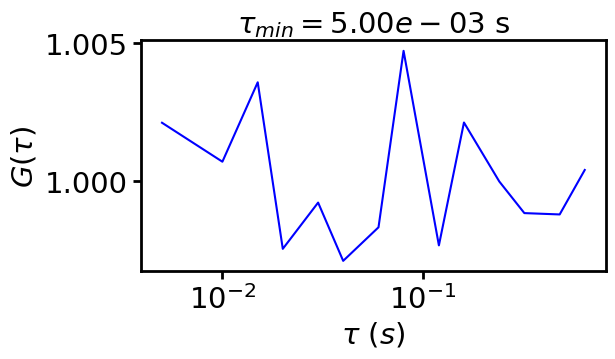

In [42]:
mi.print_class(fcs)
fcs.plot(normalize_to=None, unit="s", scale=1);

Some fcs fits are available:

In [43]:
# fcs_predict = fcs_p.fit_dark(tau, dark_lifetime, dark_occupation)
# fcs_predict = fcs_p.fit_antibunching(tau, excitation_rate, s1_lifetime)
# fcs_predict = fcs_p.fit_triplet_cis(tau, k_isc, k_T, k_01, k_10, k_iso, k_biso_eff)

## Antibunching

Alternatively, you can focus on fast time scales in a linear scale and observe photon bunching or antibunching.

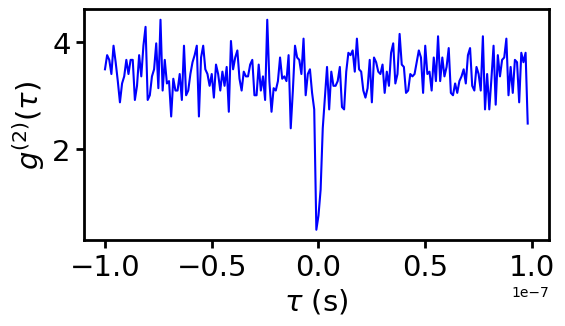

In [44]:
# sensible to tau_max and bin_width, see coincidence notebook
hist, bins = fcs_p.coincidence(
    emissions.event_time_points[: int(2e5)], tau_max=1e-7, bin_width=1e-9, seed=rng
)
fi.universal_figure(
    type_="line",
    data=[bins[:-2], hist],
    xlabel=r"$\tau$ (s)",
    ylabel=r"$g^{(2)}(\tau)$",
    scale=1,
);

## Blinking

For analyzing a fluorescence on/off process, the blinking time scales can be estimated by thresholding an emission time series.

An ON-period is a number of consecutive frames where each frame contains a minimum amount of emissions (> threshold). 

An OFF-period is a number of consecutive frames where each frame contains a maximum amount of emissions (≤ threshold). 

Each ON-period is followed by an OFF-period and vice versa.

### Emissions from a short simulation

We limit the dataset to 2000 frames for illustration purposes.

In [45]:
%%time
emissions = em.Emissions(frame_time="10us", seed=rng, bandpass=None)
emissions.simulate(transition_set=transition_set, store_time_points=False, frames=2000)
emissions

CPU times: total: 1.2 s
Wall time: 1.22 s


In [46]:
threshold: int = 5

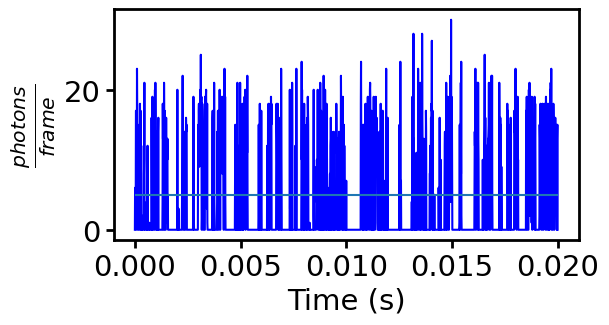

In [47]:
emissions.plot_time_series(scale=1)
plt.hlines(threshold, xmin=0, xmax=0.02)

In [48]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [49]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x00000236AC722660>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000236AC77FB10>
_________________________________________________________________
on_periods = array([ 2,  2,  2,  1,  5,  1,  3,  1,  2,  3,  ...,  1,  2,  3,
        6,  5,  2,  7,  6, 10,  2])
_________________________________________________________________
off_periods = array([ 2,  3,  2,  8,  2, 12, 14, 18,  1, 10,  ...,  5,  1,  1,  1,
        3,  1,  3,  7,  3,  1])
_________________________________________________________________
on_periods_frames = array([   1,    5,   10,   14,   23,   30,   43,...1944, 1953, 1959, 1964, 1978, 1987,
       1998])
_________________________________________________________________
off_periods_frames = array([   3,    7,   12,   15,   28,   31,   46,... 1939, 1943, 1950, 1958, 1961, 1971, 1984, 1997])
_________________________________________________________

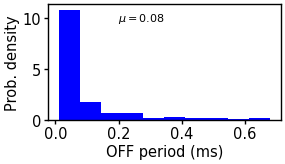

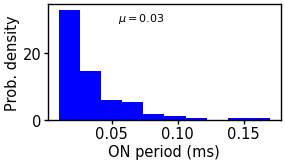

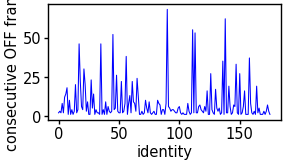

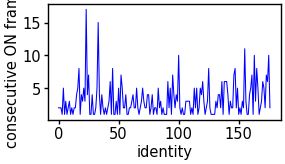

In [50]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5);

You can extract the analytical OFF statistics from the emission time series without differentiating between fluorophores.

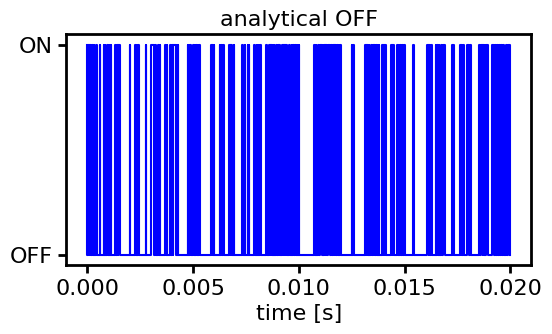

In [51]:
on_off_times_analytic, on_off_values_analytic = bl.get_analytical_off_statistics(
    off_frames=blinks.off_periods_frames,
    off_periods=blinks.off_periods,
    on_frames=blinks.on_periods_frames,
    frame_time=blinks.emissions.parameters["frame_time"],
)

bl.plot_off_statistics(
    on_off_times_analytic, on_off_values_analytic, scale=1, title="analytical OFF"
);

### Emissions from the long simulation

Get more detailed information from a complete simulation:

In [52]:
%%time
emissions = em.Emissions(frame_time="200ns", seed=rng, bandpass=None)
emissions.extract(simulation=simulation)
emissions

CPU times: total: 1.47 s
Wall time: 1.46 s


In [53]:
blinks = bl.Blinking(emissions, threshold=threshold)
blinks

In [54]:
mi.print_class(blinks)

Attributes of <fluopy.blinking.Blinking object at 0x00000236B44016D0>:
.................................................................
emissions = <fluopy.emissions.Emissions object at 0x00000236B3ECC9D0>
_________________________________________________________________
on_periods = array([1, 1])
_________________________________________________________________
off_periods = array([1920216])
_________________________________________________________________
on_periods_frames = array([1462038, 3382255])
_________________________________________________________________
off_periods_frames = array([1462039])
_________________________________________________________________




array([[<Axes: xlabel='identity', ylabel='consecutive ON frames'>]],
      dtype=object)

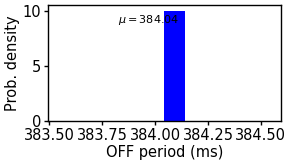

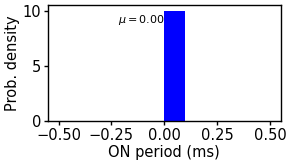

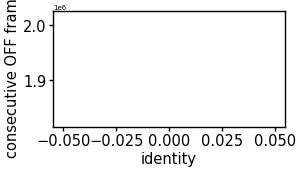

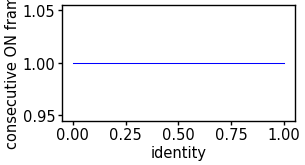

In [55]:
# plot a histogram of OFF times
blinks.plot(
    mode="off_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a histogram of ON times
blinks.plot(
    mode="on_histogram", density=True, display_mean=True, as_time="ms", scale=0.5
)

# plot a time series of OFF times
blinks.plot(mode="off_frame_series", scale=0.5)

# plot a time series of ON times
blinks.plot(mode="on_frame_series", scale=0.5)